In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Churn_Modelling.csv')
print(df.shape)
df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography 

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


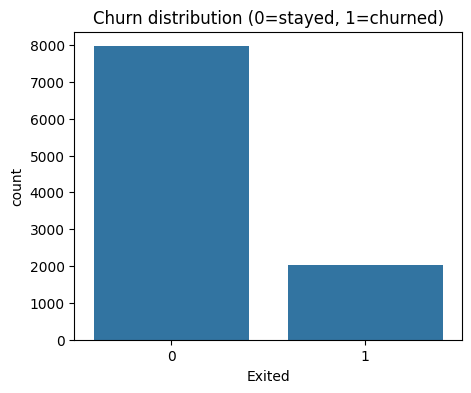

In [ ]:
print(df['Exited'].value_counts())
print(df['Exited'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(x='Exited', data=df)
plt.title('Churn distribution (0=stayed, 1=churned)')
plt.show()

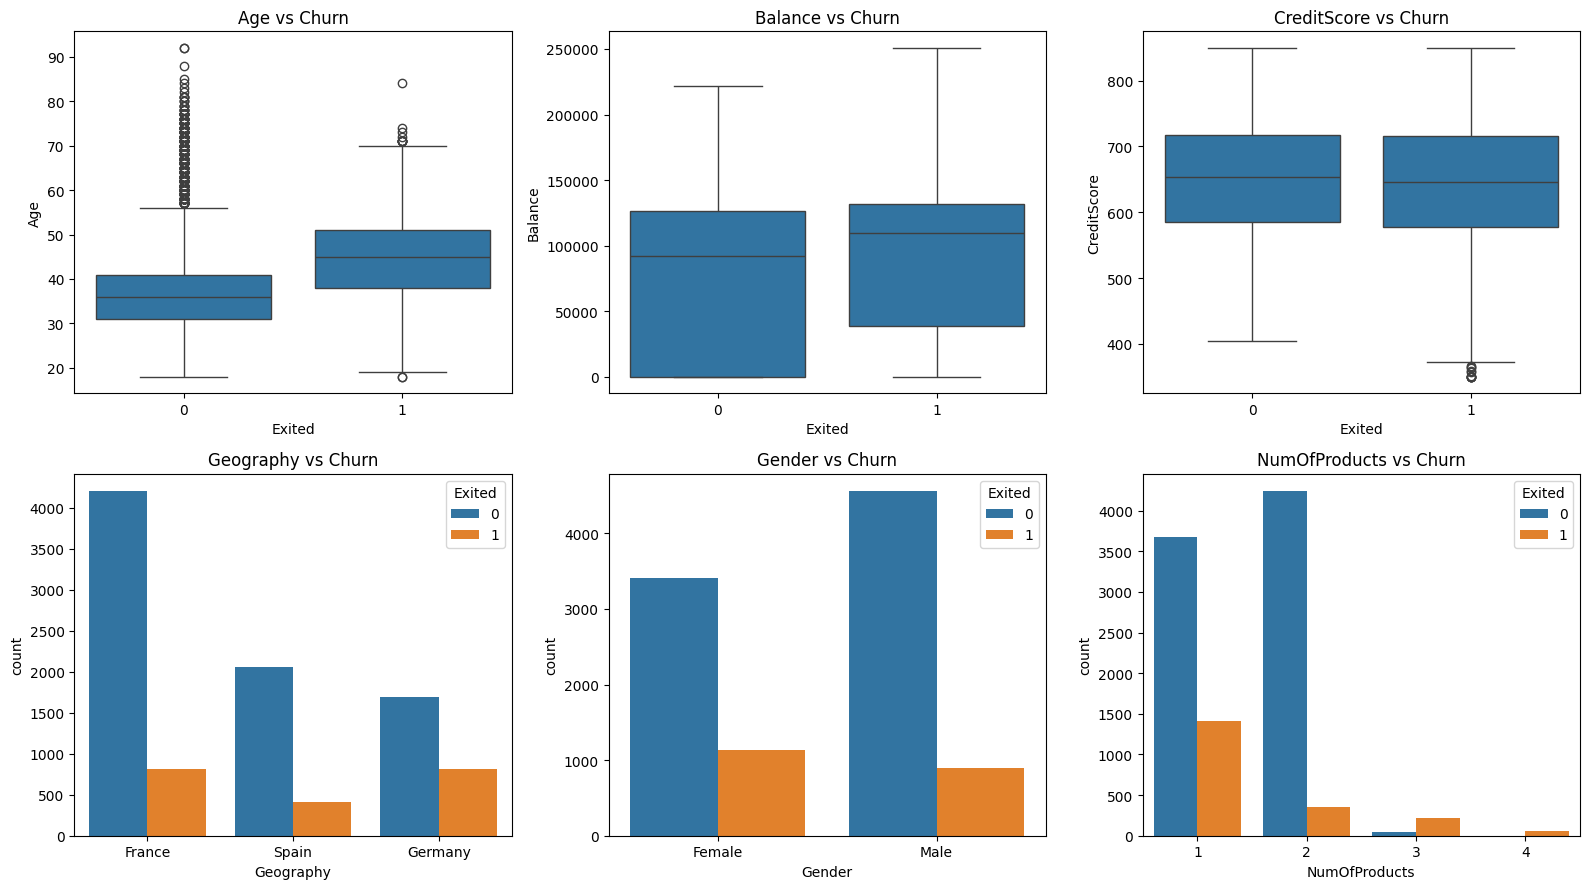

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.boxplot(x='Exited', y='Age', data=df, ax=axes[0,0])
axes[0,0].set_title('Age vs Churn')

sns.boxplot(x='Exited', y='Balance', data=df, ax=axes[0,1])
axes[0,1].set_title('Balance vs Churn')

sns.boxplot(x='Exited', y='CreditScore', data=df, ax=axes[0,2])
axes[0,2].set_title('CreditScore vs Churn')

sns.countplot(x='Geography', hue='Exited', data=df, ax=axes[1,0])
axes[1,0].set_title('Geography vs Churn')

sns.countplot(x='Gender', hue='Exited', data=df, ax=axes[1,1])
axes[1,1].set_title('Gender vs Churn')

sns.countplot(x='NumOfProducts', hue='Exited', data=df, ax=axes[1,2])
axes[1,2].set_title('NumOfProducts vs Churn')

plt.tight_layout()
plt.show()

In [ ]:
# Drop identifier columns that don't generalize
drop_cols = ['RowNumber', 'CustomerId', 'Surname']
df_model = df.drop(columns=drop_cols)

# Encode categoricals
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(df_model.shape)
df_model.head()

Categorical columns to encode: ['Geography', 'Gender']
(10000, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)
print("Churn rate - train:", y_train.mean(), " test:", y_test.mean())

(8000, 11) (2000, 11)
Churn rate - train: 0.20375  test: 0.2035


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
}

trained = {}
for name, model in models.items():
    print(f"Training {name}...")
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)
    trained[name] = model
print("Done.")

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Done.



===== Logistic Regression =====
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1593
     Churned       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

ROC-AUC: 0.7771

===== Random Forest =====
              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90      1593
     Churned       0.59      0.64      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000

ROC-AUC: 0.8612

===== Gradient Boosting =====
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1593
     Churned       0.77      0.50      0.60       407

    accuracy                           0.87      2000
   ma

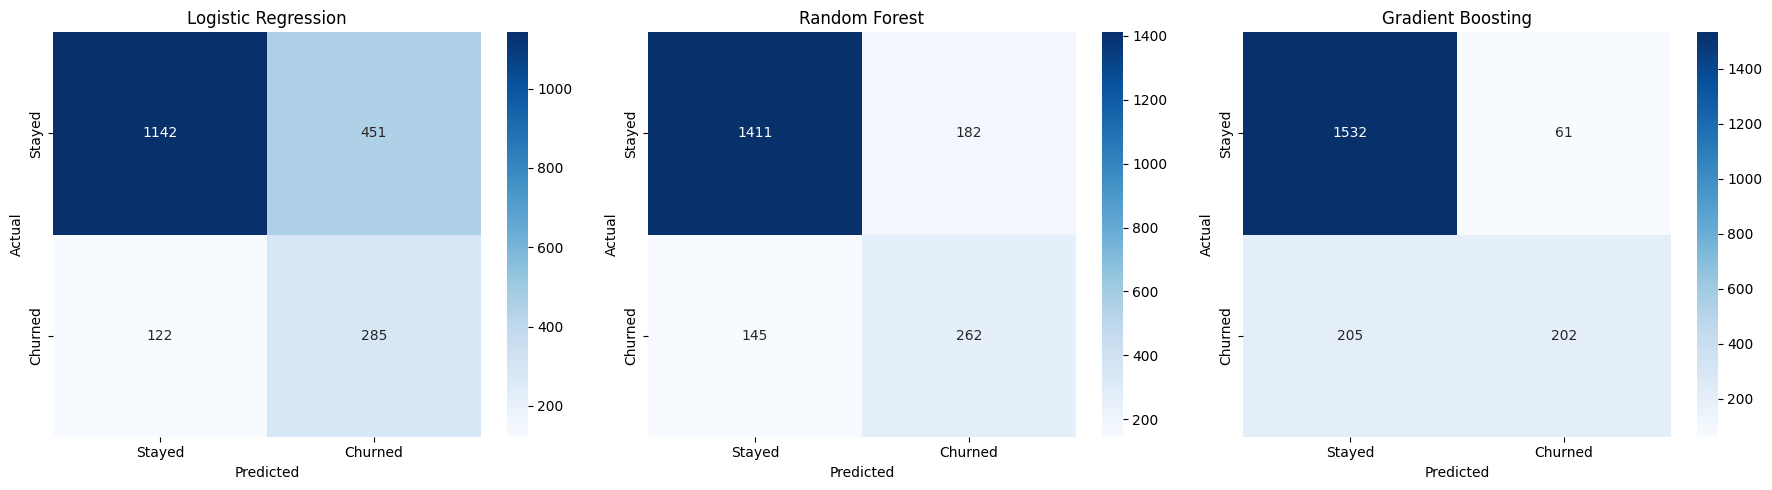

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(trained.items()):
    X_eval = X_test_scaled if name == "Logistic Regression" else X_test
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = auc

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))
    print(f"ROC-AUC: {auc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

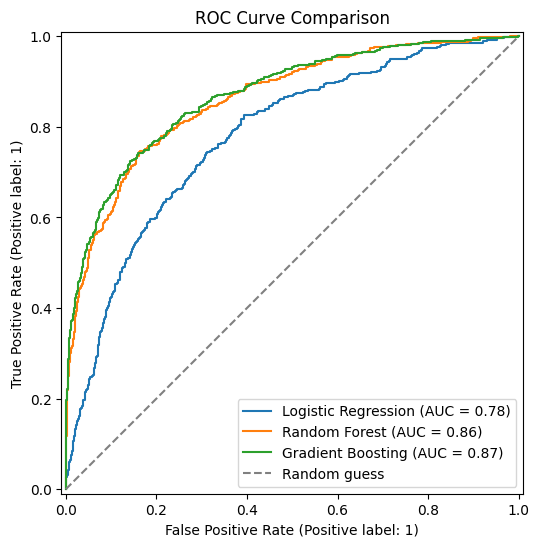

,Model,ROC-AUC
2,Gradient Boosting,0.869347
1,Random Forest,0.861211
0,Logistic Regression,0.777138


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in trained.items():
    X_eval = X_test_scaled if name == "Logistic Regression" else X_test
    RocCurveDisplay.from_estimator(model, X_eval, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'ROC-AUC']).sort_values('ROC-AUC', ascending=False)
results_df

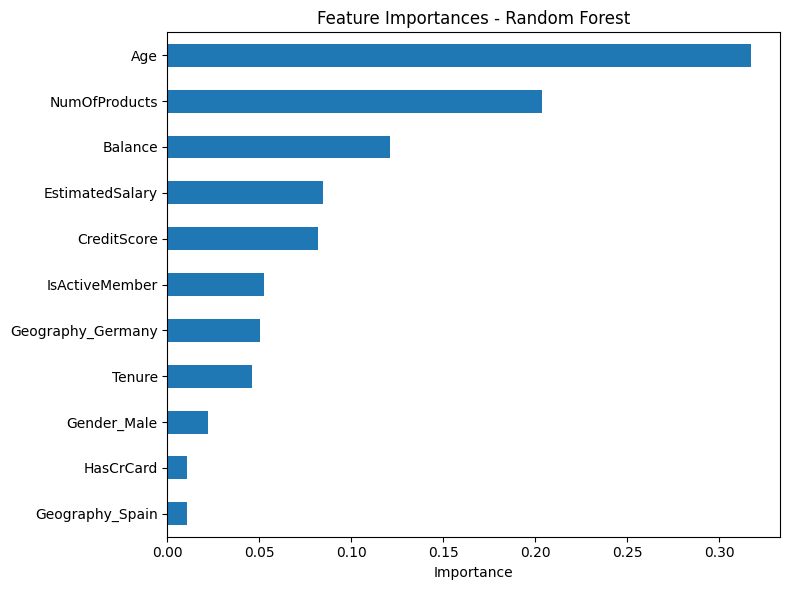

In [ ]:
importances = pd.Series(trained["Random Forest"].feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh')
plt.title('Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()